In [ ]:
# !unzip /content/archive.zip

Archive:  /content/archive.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: test_labels.csv         
  inflating: train.csv               


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
tlabel_df = pd.read_csv('test_labels.csv')

In [ ]:
train_df.shape

(159571, 8)

In [ ]:
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
train_df.drop(columns = ['id'],inplace = True)

In [ ]:
train_df.isnull().sum()

,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [ ]:
count = train_df[['toxic','severe_toxic','obscene','threat','insult','identity_hate']].sum()
labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

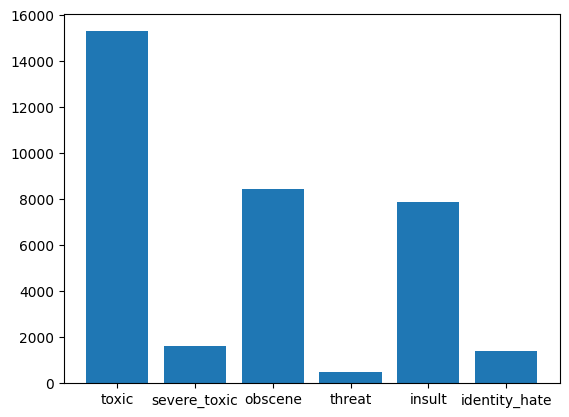

In [ ]:
plt.bar(labels,count)
plt.show()

In [ ]:
count

,0
toxic,15294
severe_toxic,1595
obscene,8449
threat,478
insult,7877
identity_hate,1405


In [ ]:
multi_label_count = (train_df[labels].sum(axis = 1) > 1).sum()

In [ ]:
multi_label_count

np.int64(9865)

In [ ]:
clean_label_count = (train_df[labels].sum(axis = 1) == 0).sum()

In [ ]:
clean_label_count

np.int64(143346)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = train_df[['comment_text']]
y = train_df.iloc[:,1:]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [ ]:
# Lower
def to_lower(text):
  return text.str.lower()

X_train = X_train.apply(to_lower)
X_test = X_test.apply(to_lower)

In [ ]:
X_train.head()

,comment_text
140030,grandma terri should burn in trash \ngrandma t...
159124,", 9 may 2009 (utc)\nit would be easiest if you..."
60006,"""\n\nthe objectivity of this discussion is dou..."
65432,shelly shock\nshelly shock is. . .( )
154979,i do not care. refer to ong teng cheong talk p...


In [ ]:
X_test.head()

,comment_text
119105,"geez, are you forgetful! we've already discus..."
131631,carioca rfa \n\nthanks for your support on my ...
125326,"""\n\n birthday \n\nno worries, it's what i do ..."
111256,pseudoscience category? \n\ni'm assuming that ...
83590,"(and if such phrase exists, it would be provid..."


In [ ]:
# Removing urls/punctuations/numbers
import re
def rem(text):
  text = text.str.replace(r"http\S+|www\S+","",regex = True)
  text = text.str.replace(r"[^\w\s]","",regex = True)
  text = text.str.replace(r"\d+","",regex = True)
  text = text.str.strip()
  return text

X_train = X_train.apply(rem)
X_test = X_test.apply(rem)

In [ ]:
X_train.head()

,comment_text
140030,grandma terri should burn in trash \ngrandma t...
159124,may utc\nit would be easiest if you were to a...
60006,the objectivity of this discussion is doubtful...
65432,shelly shock\nshelly shock is
154979,i do not care refer to ong teng cheong talk pa...


In [ ]:
X_test.head()

,comment_text
119105,geez are you forgetful weve already discussed...
131631,carioca rfa \n\nthanks for your support on my ...
125326,birthday \n\nno worries its what i do enjoy ur...
111256,pseudoscience category \n\nim assuming that th...
83590,and if such phrase exists it would be provided...


In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords

In [ ]:
def rem_sw(text):
  stop_words = set(stopwords.words('english'))
  return " ".join([w for w in text.split() if w not in stop_words])

In [ ]:
X_train['comment_text'] = X_train['comment_text'].apply(rem_sw)
X_test['comment_text'] = X_test['comment_text'].apply(rem_sw)

In [ ]:
X_train.head()

,comment_text
140030,grandma terri burn trash grandma terri trash h...
159124,may utc would easiest admit member involved po...
60006,objectivity discussion doubtful nonexistent in...
65432,shelly shock shelly shock
154979,care refer ong teng cheong talk page la goutte...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer(max_features = 20000,ngram_range = (1,2))

In [ ]:
X_train_vec = vectorizer.fit_transform(X_train['comment_text'])

In [ ]:
X_test_vec = vectorizer.transform(X_test['comment_text'])

In [ ]:
X_train_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3765365 stored elements and shape (127656, 20000)>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

In [ ]:
X = train_df['comment_text']
y = train_df.iloc[:,1:]
models = {
    'Naive Bayes' : MultinomialNB(),
    'Logistic Regression' : LogisticRegression(max_iter = 1000),
    'Linear SVC' : LinearSVC(max_iter = 2000),
    'Decision Tree' : DecisionTreeClassifier(max_depth = 20)
}

for name, model in models.items():
  pipeline = Pipeline([
      ('tfidf',TfidfVectorizer(max_features = 20000,ngram_range = (1,2))),
      ('clf',OneVsRestClassifier(model))
  ])

  scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='f1_weighted',
    error_score='raise',
    n_jobs = -1
  )
  print(f"{name} : Mean F1: {scores.mean()}")

Naive Bayes : Mean F1: 0.6024007864227519
Logistic Regression : Mean F1: 0.668312199337828
Linear SVC : Mean F1: 0.7093900968613763
Decision Tree : Mean F1: 0.6216965868698098


In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_svm = SGDClassifier(
    loss="hinge",
    penalty="l2",
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3,
    class_weight="balanced",
    random_state=42
)

pipeline = Pipeline([
    ('tfidf',TfidfVectorizer(max_features = 20000,ngram_range = (1,2))),
    ('clf',OneVsRestClassifier(sgd_svm))
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)

print("Mean F1:", scores.mean())

Mean F1: 0.6550381648016557


In [ ]:
from sklearn.model_selection import RandomizedSearchCV


svc = OneVsRestClassifier(LinearSVC())
param_dist = {
    'estimator__C': [0.01, 0.1, 1, 10, 100],
    'estimator__class_weight': [None, 'balanced'],
}


rscv = RandomizedSearchCV(
    svc,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
)

rscv.fit(X_train_vec, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=OneVsRestClassifier(estimator=LinearSVC()),
                   n_jobs=-1,
                   param_distributions={'estimator__C': [0.01, 0.1, 1, 10, 100],
                                        'estimator__class_weight': [None,
                                                                    'balanced']},
                   scoring='f1_weighted', verbose=1)

In [ ]:
rscv.best_score_

np.float64(0.6975477152732572)

In [ ]:
rscv.best_params_

{'estimator__class_weight': None, 'estimator__C': 1}

In [ ]:
from sklearn.linear_model import LogisticRegression

param_dist_lr = {
    "estimator__C": [0.01, 0.1, 1, 10, 100],
    "estimator__penalty": ["l2"],
    "estimator__class_weight": [None, "balanced"]
}

lr = OneVsRestClassifier(LogisticRegression(max_iter=2000))

rs_lr = RandomizedSearchCV(
    lr,
    param_distributions=param_dist_lr,
    n_iter=10,
    scoring="f1_weighted",
    cv=5,
    verbose=1,
    n_jobs=-1
)
rs_lr.fit(X_train_vec,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=OneVsRestClassifier(estimator=LogisticRegression(max_iter=2000)),
                   n_jobs=-1,
                   param_distributions={'estimator__C': [0.01, 0.1, 1, 10, 100],
                                        'estimator__class_weight': [None,
                                                                    'balanced'],
                                        'estimator__penalty': ['l2']},
                   scoring='f1_weighted', verbose=1)

In [ ]:
rs_lr.best_score_

np.float64(0.7001797721710241)

In [ ]:
rs_lr.best_params_

{'estimator__penalty': 'l2',
 'estimator__class_weight': None,
 'estimator__C': 10}

In [ ]:
lr_clf = LogisticRegression(C = 10,class_weight = None,max_iter = 2000,penalty = 'l2')
lr_clf = OneVsRestClassifier(lr_clf)
lr_clf.fit(X_train_vec,y_train)

OneVsRestClassifier(estimator=LogisticRegression(C=10, max_iter=2000))

In [ ]:
y_pred = lr_clf.predict(X_test_vec)

In [ ]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score

In [ ]:
accuracy_score(y_test,y_pred)

0.918314272285759

In [ ]:
print(precision_score(y_test, y_pred, average='macro'))
print(recall_score(y_test, y_pred, average='macro'))
print(f1_score(y_test, y_pred, average='macro'))

0.6962738162337184
0.4470035562882897
0.5355910726380261


In [ ]:
print(precision_score(y_test, y_pred, average='weighted'))
print(recall_score(y_test, y_pred, average='weighted'))
print(f1_score(y_test, y_pred, average='weighted'))

0.8192881869774564
0.6174724342663274
0.7018505989859466


In [ ]:
label_names = y.columns
y_prob = lr_clf.predict_proba(X_test_vec)

thresholds = np.arange(0.1, 0.9, 0.05)
best_thresholds = {}

for i, label in enumerate(label_names):
    best_f1 = 0
    best_t = 0.5

    for t in thresholds:
        y_pred_thresholded = (y_prob[:, i] >= t).astype(int)

        f1 = f1_score(y_test.iloc[:, i], y_pred_thresholded)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds[label] = best_t

print(best_thresholds)

{'toxic': np.float64(0.40000000000000013), 'severe_toxic': np.float64(0.20000000000000004), 'obscene': np.float64(0.30000000000000004), 'threat': np.float64(0.1), 'insult': np.float64(0.25000000000000006), 'identity_hate': np.float64(0.20000000000000004)}


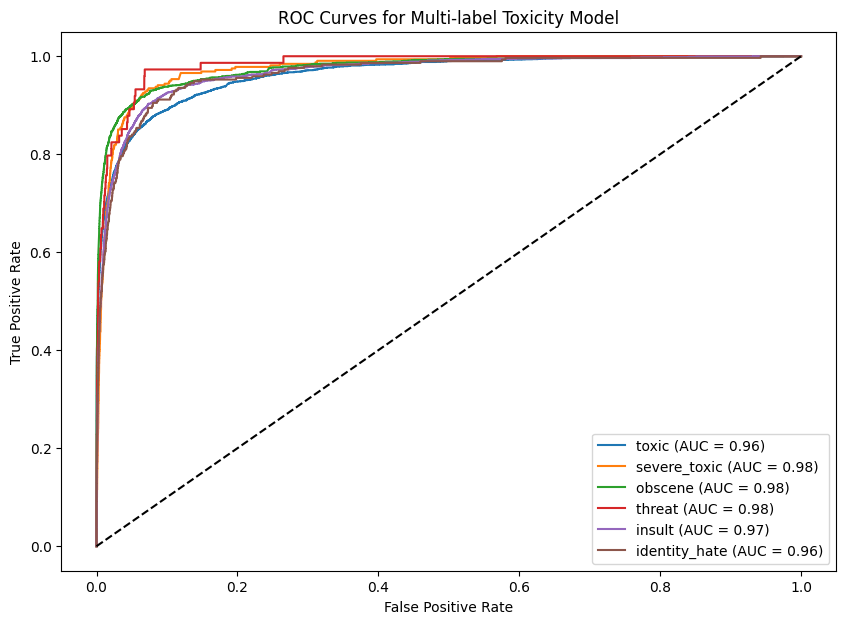

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 7))

for i, label in enumerate(label_names):
    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Multi-label Toxicity Model")
plt.legend()
plt.show()

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

def cleaning_string(text):
  stop_words = set(stopwords.words('english'))
  text = text.lower()
  text = re.sub(r"http\S+|www\S+","",text)
  text = re.sub(r"[^\w\s]","",text)
  text = re.sub(r"\d+","",text)
  text = text.strip()
  return " ".join([w for w in text.split() if w not in stop_words])

In [ ]:
import joblib

In [ ]:
joblib.dump(lr_clf,'toxicity_model.pkl')

['toxicity_model.pkl']

In [ ]:
joblib.dump(vectorizer,'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [ ]:
joblib.dump(best_thresholds, "thresholds.pkl")

['thresholds.pkl']